# Actividad 4 — Calidad de los Datos

**Proyecto:** Prediccion de Produccion de Limon en el Peru  
**Pipeline:** Fase 1 — Ingenieria de Datos  

---

## Objetivo
Presentar el resumen consolidado de la auditoria de calidad de las 4 fuentes. Cada problema detectado incluye su decision tecnica documentada para la Actividad 5.

## Regla de esta actividad
> **Solo se detecta y documenta. No se corrige nada aqui.**

## Graficos incluidos
| # | Fuente | Grafico |
|---|--------|---------|
| G1 | MIDAGRI | Nulos por columna |
| G2 | MIDAGRI | Outliers IQR en produccion y precio |
| G3 | MIDAGRI | Cobertura temporal por departamento |
| G4 | INDECI | Nulos en columnas clave |
| G5 | INDECI | Valores unicos en columna mes |
| G6 | INDECI | Cobertura temporal año x mes |
| G7 | NASA | Nulos por variable climatica |
| G8 | NASA | Rangos fisicos de las 8 variables |
| G9 | NASA | Cobertura temporal por provincia |
| G10 | Agraria | Nulos por columna |
| G11 | Agraria | Duplicados y noticias sin contenido |
| G12 | Todas | Tabla resumen consolidada |


## Configuracion inicial


In [1]:
import os, sys, json, glob, warnings, unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']

def normalizar(t):
    if not isinstance(t, str): return ''
    t = unicodedata.normalize('NFKD', t).encode('ASCII','ignore').decode('utf-8')
    return t.upper().strip()

def reporte_nulos(df, nombre):
    nulos = df.isnull().sum()
    pct   = (nulos / len(df) * 100).round(2)
    r = pd.DataFrame({'nulos': nulos, 'pct': pct})
    r = r[r['nulos'] > 0].sort_values('nulos', ascending=False)
    print(f'=== NULOS EN {nombre} ===')
    if len(r) == 0:
        print('  Sin valores nulos.')
    else:
        print(r.to_string())
    print()
    return r

def outliers_iqr(serie, nombre):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    mask = (serie < lower) | (serie > upper)
    n_out = mask.sum()
    pct = n_out / len(serie) * 100
    print(f'{nombre}: Q1={Q1:.2f} Q3={Q3:.2f} IQR={IQR:.2f}')
    print(f'  Limite inferior: {lower:.2f} | Limite superior: {upper:.2f}')
    print(f'  Outliers: {n_out} ({pct:.2f}%)')
    return lower, upper, mask

print('Config cargado OK | Raiz:', os.getcwd())


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## Configuracion de carpeta de calidad


In [2]:
import os
os.makedirs(OUTPUT['calidad'], exist_ok=True)
print('Carpeta de calidad lista:', OUTPUT['calidad'])


Carpeta de calidad lista: pipeline/output/04_calidad/


---
# 1. Calidad — MIDAGRI


## Carga de datos


In [3]:
xl = pd.ExcelFile(SOURCES['midagri'])
dfs = [pd.read_excel(SOURCES['midagri'], sheet_name=s) for s in xl.sheet_names]
df_m = pd.concat(dfs, ignore_index=True)
df_limon = df_m[df_m['dsc_Cultivo'].str.upper().str.contains('LIMON', na=False)].copy()
print(f'Dataset completo: {df_m.shape}')
print(f'Solo LIMON: {df_limon.shape}')
print(f'Columnas: {df_m.columns.tolist()}')


Dataset completo: (1596748, 10)
Solo LIMON: (40284, 10)
Columnas: ['anho', 'mes', 'COD_UBIGEO', 'Dpto', 'Prov', 'Dist', 'dsc_Cultivo', 'PRODUCCION(t)', 'COSECHA (ha)', 'MTO_PRECCHAC (S/ x kg)']


## 4.1 Auditoria de Nulos


=== NULOS EN MIDAGRI COMPLETO ===
  Sin valores nulos.

=== NULOS EN MIDAGRI LIMON ===
  Sin valores nulos.



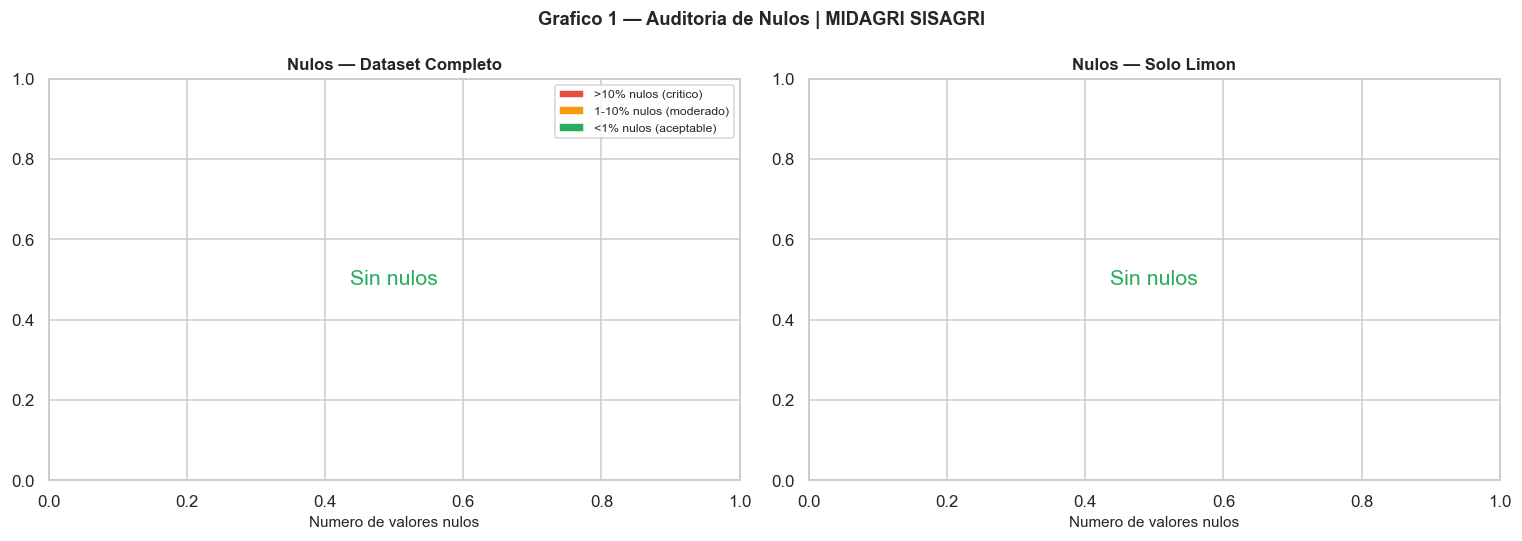

Guardado: pipeline/output/04_calidad/act04_midagri_g1_nulos.png


In [4]:
# Nulos en dataset completo
r_nulos = reporte_nulos(df_m, 'MIDAGRI COMPLETO')
r_nulos_limon = reporte_nulos(df_limon, 'MIDAGRI LIMON')

# Grafico G1: nulos por columna
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df_plot, titulo in zip(axes,
    [df_m, df_limon],
    ['Dataset Completo', 'Solo Limon']):
    nulos = df_plot.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=True)
    if len(nulos) == 0:
        ax.text(0.5, 0.5, 'Sin nulos', ha='center', va='center',
                transform=ax.transAxes, fontsize=14, color='#27ae60')
    else:
        pct = (nulos / len(df_plot) * 100)
        colors = ['#e74c3c' if p > 10 else '#f39c12' if p > 1 else '#27ae60' for p in pct]
        ax.barh(nulos.index, nulos.values, color=colors, edgecolor='white')
        for i, (val, p) in enumerate(zip(nulos.values, pct)):
            ax.text(val+0.5, i, f'{val:,} ({p:.1f}%)', va='center', fontsize=8)
    ax.set_xlabel('Numero de valores nulos', fontsize=10)
    ax.set_title(f'Nulos — {titulo}', fontsize=11, fontweight='bold')

from matplotlib.patches import Patch
legend = [Patch(facecolor='#e74c3c', label='>10% nulos (critico)'),
          Patch(facecolor='#f39c12', label='1-10% nulos (moderado)'),
          Patch(facecolor='#27ae60', label='<1% nulos (aceptable)')]
axes[0].legend(handles=legend, fontsize=8)
plt.suptitle('Grafico 1 — Auditoria de Nulos | MIDAGRI SISAGRI',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_midagri_g1_nulos.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Valores nulos en columnas numericas (produccion, precio, cosecha)  
**Magnitud:** Ver tabla de nulos arriba — porcentaje exacto por columna  
**Decision (Actividad 5):** Imputar con la mediana por departamento-mes si < 5%. Eliminar filas si > 20%.


## 4.2 Auditoria de Outliers (IQR)


PRODUCCION(t): Q1=2.00 Q3=15.00 IQR=13.00
  Limite inferior: -17.50 | Limite superior: 34.50
  Outliers: 5924 (14.71%)

MTO_PRECCHAC (S/ x kg): Q1=0.80 Q3=1.55 IQR=0.75
  Limite inferior: -0.32 | Limite superior: 2.67
  Outliers: 2838 (7.04%)

COSECHA (ha): Q1=2.00 Q3=10.00 IQR=8.00
  Limite inferior: -10.00 | Limite superior: 22.00
  Outliers: 387 (15.30%)



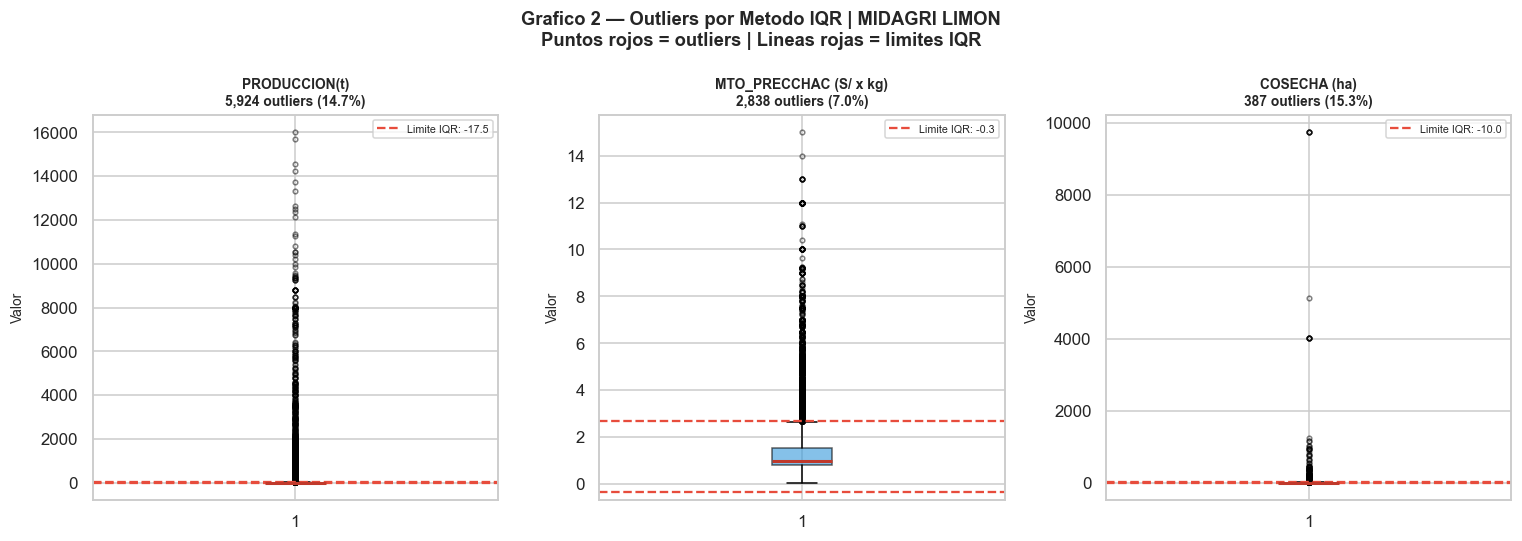

Guardado: pipeline/output/04_calidad/act04_midagri_g2_outliers.png


In [5]:
cols_num = ['PRODUCCION(t)', 'MTO_PRECCHAC (S/ x kg)', 'COSECHA (ha)']
cols_num = [c for c in cols_num if c in df_limon.columns]

resultados_iqr = {}
for col in cols_num:
    serie = df_limon[col].dropna()
    serie = serie[serie > 0]
    lower, upper, mask_out = outliers_iqr(serie, col)
    resultados_iqr[col] = {'lower': lower, 'upper': upper,
                            'n_outliers': mask_out.sum(),
                            'pct': mask_out.sum()/len(serie)*100}
    print()

# Grafico G2: boxplots con outliers
fig, axes = plt.subplots(1, len(cols_num), figsize=(14, 5))
if len(cols_num) == 1: axes = [axes]
for ax, col in zip(axes, cols_num):
    data = df_limon[col].dropna()
    data = data[data > 0]
    bp = ax.boxplot(data, patch_artist=True, vert=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='#c0392b', linewidth=2),
                    flierprops=dict(marker='o', color='#e74c3c',
                                    markersize=3, alpha=0.5))
    info = resultados_iqr[col]
    ax.axhline(info['lower'], color='#e74c3c', linestyle='--',
               linewidth=1.5, label=f'Limite IQR: {info["lower"]:.1f}')
    ax.axhline(info['upper'], color='#e74c3c', linestyle='--', linewidth=1.5)
    ax.set_title(f'{col}\n{info["n_outliers"]:,} outliers ({info["pct"]:.1f}%)',
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Valor', fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Grafico 2 — Outliers por Metodo IQR | MIDAGRI LIMON\n'
             'Puntos rojos = outliers | Lineas rojas = limites IQR',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_midagri_g2_outliers.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Outliers extremos en produccion, precio y cosecha  
**Magnitud:** Ver tabla IQR arriba — numero y porcentaje exacto por variable  
**Decision (Actividad 5):** Aplicar filtro IQR (1.5x) en la Actividad 5. Registrar cuantos registros se eliminan.


## 4.3 Cobertura Temporal por Departamento


Total meses en el dataset: 116
Departamentos con cobertura completa: 14
Departamentos con cobertura incompleta: 9

Departamentos incompletos:
  LIMA: 20/116 meses (17%)
  AREQUIPA: 23/116 meses (20%)
  PASCO: 28/116 meses (24%)
  MOQUEGUA: 52/116 meses (45%)
  PUNO: 52/116 meses (45%)
  HUANCAVELICA: 96/116 meses (83%)
  ICA: 100/116 meses (86%)
  CUSCO: 114/116 meses (98%)
  AYACUCHO: 114/116 meses (98%)


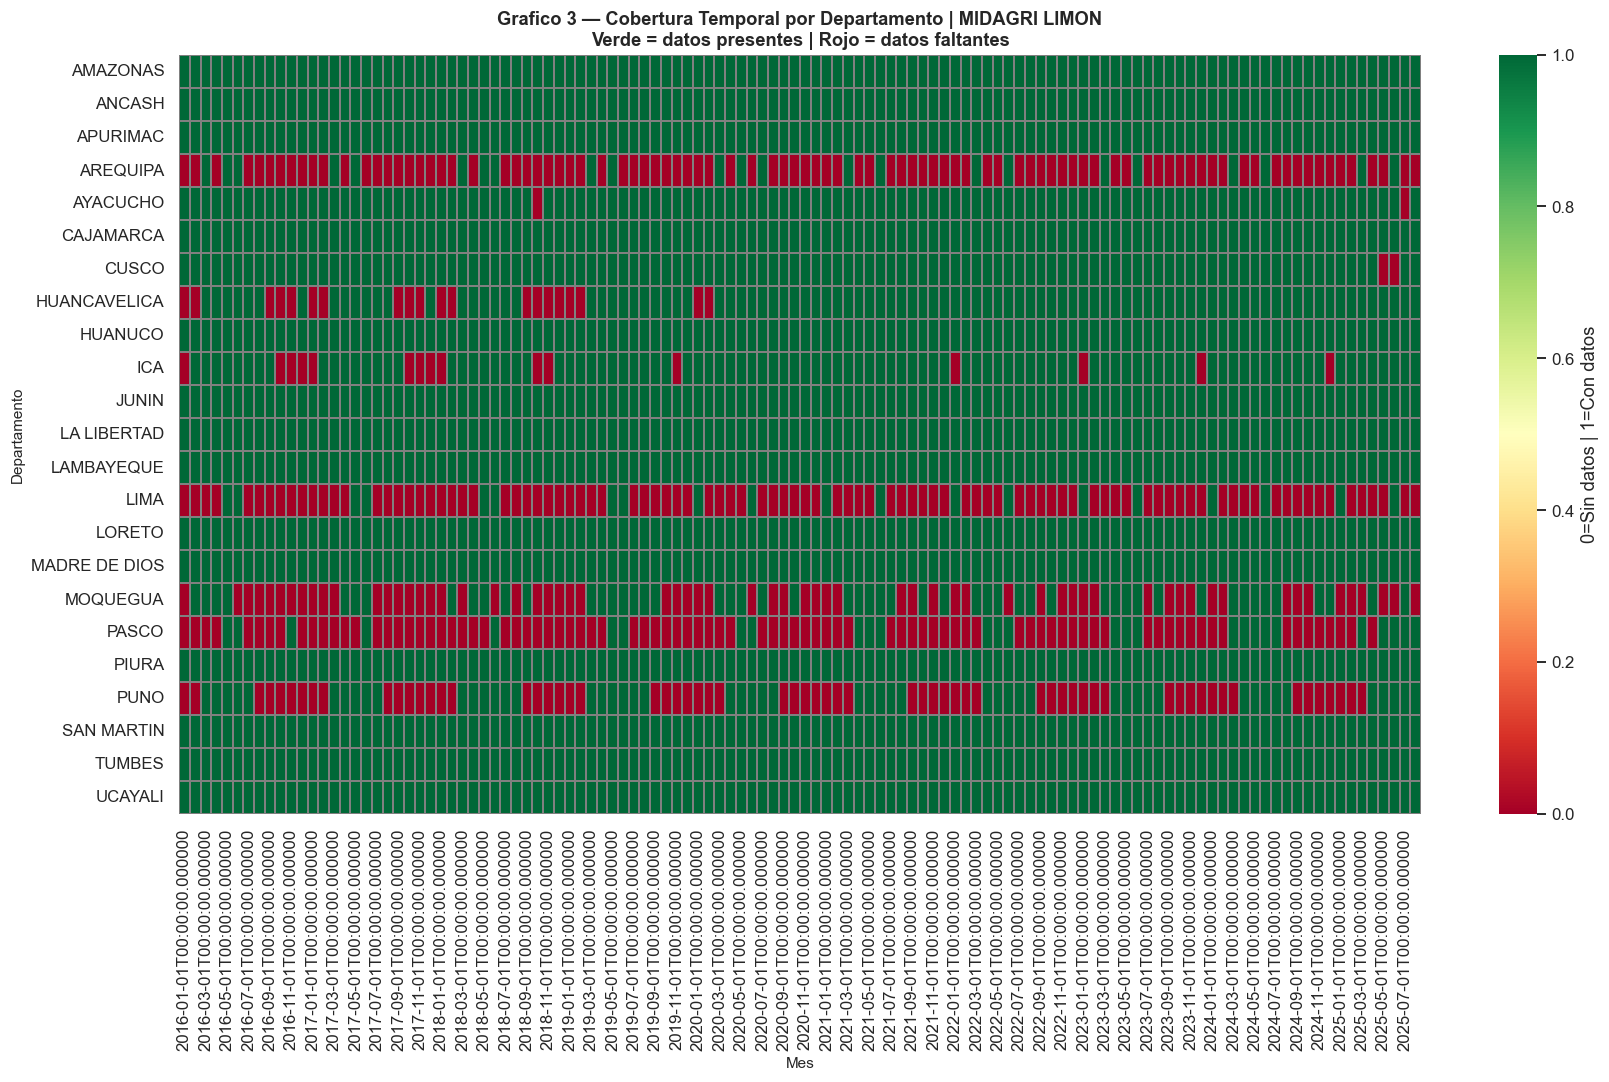

Guardado: pipeline/output/04_calidad/act04_midagri_g3_cobertura.png


In [6]:
# Verificar si hay meses faltantes por departamento
df_limon['fecha_mes'] = pd.to_datetime(
    df_limon['anho'].astype(str) + '-' + df_limon['mes'].astype(str).str.zfill(2) + '-01'
)
cobertura = df_limon.groupby(['Dpto','fecha_mes']).size().unstack(fill_value=0)
cobertura_bool = (cobertura > 0).astype(int)

# Departamentos con cobertura incompleta
total_meses = cobertura_bool.shape[1]
meses_por_dpto = cobertura_bool.sum(axis=1)
dptos_incompletos = meses_por_dpto[meses_por_dpto < total_meses]
print(f'Total meses en el dataset: {total_meses}')
print(f'Departamentos con cobertura completa: {(meses_por_dpto == total_meses).sum()}')
print(f'Departamentos con cobertura incompleta: {len(dptos_incompletos)}')
if len(dptos_incompletos) > 0:
    print()
    print('Departamentos incompletos:')
    for dpto, n in dptos_incompletos.sort_values().items():
        print(f'  {dpto}: {n}/{total_meses} meses ({n/total_meses*100:.0f}%)')

# Grafico G3: heatmap cobertura
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(cobertura_bool, cmap='RdYlGn', ax=ax,
            cbar_kws={'label': '0=Sin datos | 1=Con datos'},
            linewidths=0.1, linecolor='gray')
ax.set_title('Grafico 3 — Cobertura Temporal por Departamento | MIDAGRI LIMON\n'
             'Verde = datos presentes | Rojo = datos faltantes',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mes', fontsize=10)
ax.set_ylabel('Departamento', fontsize=10)
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_midagri_g3_cobertura.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Departamentos con series temporales incompletas (meses faltantes)  
**Magnitud:** Ver tabla de departamentos incompletos arriba  
**Decision (Actividad 5):** En la Actividad 5 se evaluara excluir departamentos con < 80% de cobertura temporal.


## 4.4 Inconsistencias en Nombres Geograficos


In [7]:
# Detectar variaciones en nombres de departamentos y provincias
print('=== VARIACIONES EN NOMBRES DE DEPARTAMENTOS ===')
dptos_unicos = sorted(df_m['Dpto'].dropna().unique().tolist())
print(f'Total departamentos unicos: {len(dptos_unicos)}')

# Agrupar por nombre normalizado para detectar variantes
df_m['Dpto_norm'] = df_m['Dpto'].apply(normalizar)
variantes = df_m.groupby('Dpto_norm')['Dpto'].unique()
variantes_multiples = variantes[variantes.apply(len) > 1]

if len(variantes_multiples) > 0:
    print(f'Departamentos con variantes de nombre: {len(variantes_multiples)}')
    for norm, variants in variantes_multiples.items():
        print(f'  {norm}: {list(variants)}')
else:
    print('Sin variantes de nombre detectadas en departamentos.')

print()
print('=== VARIACIONES EN NOMBRES DE PROVINCIAS ===')
df_m['Prov_norm'] = df_m['Prov'].apply(normalizar)
variantes_prov = df_m.groupby('Prov_norm')['Prov'].unique()
variantes_prov_mult = variantes_prov[variantes_prov.apply(len) > 1]
print(f'Provincias con variantes de nombre: {len(variantes_prov_mult)}')
if len(variantes_prov_mult) > 0:
    for norm, variants in list(variantes_prov_mult.items())[:10]:
        print(f'  {norm}: {list(variants)}')

# Reporte de calidad MIDAGRI
reporte = [
    'REPORTE DE CALIDAD — MIDAGRI SISAGRI',
    '=' * 60,
    f'Registros totales: {len(df_m):,}',
    f'Registros LIMON: {len(df_limon):,}',
    f'Departamentos unicos: {len(dptos_unicos)}',
    f'Variantes de nombre en dptos: {len(variantes_multiples)}',
    f'Variantes de nombre en provs: {len(variantes_prov_mult)}',
]
for col in cols_num:
    if col in resultados_iqr:
        info = resultados_iqr[col]
        reporte.append(f'Outliers {col}: {info["n_outliers"]:,} ({info["pct"]:.1f}%)')

reporte_txt = '\n'.join(reporte)
print()
print(reporte_txt)
with open(OUTPUT['calidad'] + 'reporte_calidad_midagri.txt', 'w', encoding='utf-8') as f:
    f.write(reporte_txt)
print()
print('[ACTIVIDAD 4 - MIDAGRI] COMPLETADA.')


=== VARIACIONES EN NOMBRES DE DEPARTAMENTOS ===
Total departamentos unicos: 25


Sin variantes de nombre detectadas en departamentos.

=== VARIACIONES EN NOMBRES DE PROVINCIAS ===


Provincias con variantes de nombre: 0

REPORTE DE CALIDAD — MIDAGRI SISAGRI
Registros totales: 1,596,748
Registros LIMON: 40,284
Departamentos unicos: 25
Variantes de nombre en dptos: 0
Variantes de nombre en provs: 0
Outliers PRODUCCION(t): 5,924 (14.7%)
Outliers MTO_PRECCHAC (S/ x kg): 2,838 (7.0%)
Outliers COSECHA (ha): 387 (15.3%)

[ACTIVIDAD 4 - MIDAGRI] COMPLETADA.


### Decision tecnica documentada

**Problema:** Variaciones en nombres geograficos (mayusculas, tildes, abreviaciones)  
**Magnitud:** Ver tabla de variantes arriba  
**Decision (Actividad 5):** En la Actividad 5 se normalizaran todos los nombres a MAYUSCULAS SIN TILDES usando unicodedata.


---
# 2. Calidad — INDECI


## Carga de datos


In [8]:
import geopandas as gpd

MESES_ES = {'ENERO':1,'FEBRERO':2,'MARZO':3,'ABRIL':4,'MAYO':5,'JUNIO':6,
            'JULIO':7,'AGOSTO':8,'SETIEMBRE':9,'SEPTIEMBRE':9,'OCTUBRE':10,
            'NOVIEMBRE':11,'DICIEMBRE':12}

dfs_shp = []
for d in sorted(glob.glob(SOURCES['indeci_shapefiles'] + 'E_*/')):
    shp = glob.glob(d + '*.shp')
    if shp:
        gdf = gpd.read_file(shp[0])
        df_tmp = pd.DataFrame(gdf.drop(columns='geometry', errors='ignore'))
        df_tmp.columns = [str(c).lower() for c in df_tmp.columns]
        dfs_shp.append(df_tmp)
df_indeci = pd.concat(dfs_shp, ignore_index=True)
print(f'Dataset INDECI: {df_indeci.shape}')
print(f'Columnas: {df_indeci.columns.tolist()[:12]}')


Dataset INDECI: (25025, 79)
Columnas: ['ide_sinpad', 'fecha', 'anho', 'mes', 'cod_ubigeo', 'departamen', 'provincia', 'distrito', 'fenomeno', 'region', 'safecta', 'sdamni']


## 4.1 Auditoria de Nulos en Columnas Clave


=== NULOS EN COLUMNAS CLAVE INDECI ===
  fenomeno                  0 nulos (0.00%)  [OK]
  departamen                0 nulos (0.00%)  [OK]
  provincia                 0 nulos (0.00%)  [OK]
  anho                      0 nulos (0.00%)  [OK]
  mes                       0 nulos (0.00%)  [OK]


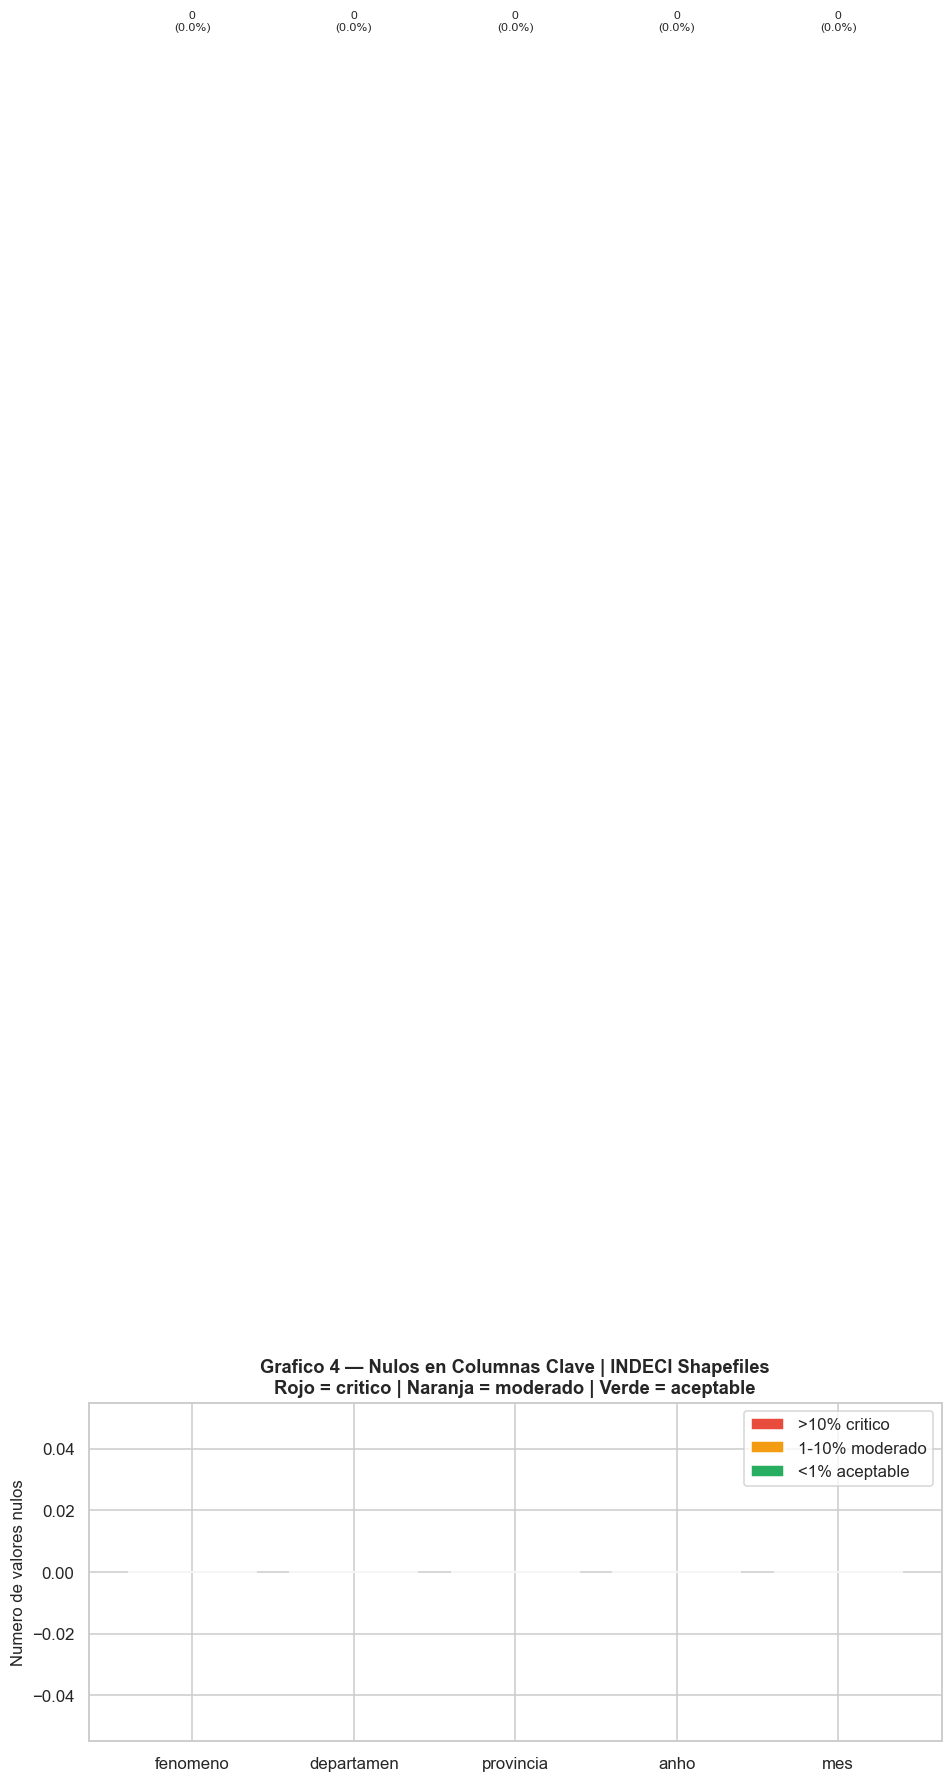

Guardado: pipeline/output/04_calidad/act04_indeci_g4_nulos.png


In [9]:
cols_clave = ['fenomeno','departamen','provincia','anho','mes']
cols_clave = [c for c in cols_clave if c in df_indeci.columns]

nulos_clave = df_indeci[cols_clave].isnull().sum()
pct_clave   = (nulos_clave / len(df_indeci) * 100).round(2)

print('=== NULOS EN COLUMNAS CLAVE INDECI ===')
for col, n, p in zip(nulos_clave.index, nulos_clave.values, pct_clave.values):
    nivel = 'CRITICO' if p > 10 else 'MODERADO' if p > 1 else 'OK'
    print(f'  {col:<20} {n:>6,} nulos ({p:.2f}%)  [{nivel}]')

# Grafico G4
fig, ax = plt.subplots(figsize=(10, 4))
colors_n = ['#e74c3c' if p > 10 else '#f39c12' if p > 1 else '#27ae60'
            for p in pct_clave.values]
bars = ax.bar(nulos_clave.index, nulos_clave.values, color=colors_n, edgecolor='white')
for bar, val, p in zip(bars, nulos_clave.values, pct_clave.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Numero de valores nulos', fontsize=11)
ax.set_title('Grafico 4 — Nulos en Columnas Clave | INDECI Shapefiles\n'
             'Rojo = critico | Naranja = moderado | Verde = aceptable',
             fontsize=12, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c', label='>10% critico'),
                   Patch(facecolor='#f39c12', label='1-10% moderado'),
                   Patch(facecolor='#27ae60', label='<1% aceptable')])
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_indeci_g4_nulos.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Nulos en columnas clave (fenomeno, departamento, fecha)  
**Magnitud:** Ver tabla de nulos arriba  
**Decision (Actividad 5):** En la Actividad 5 se eliminaran las filas con nulos en columnas clave (fenomeno, departamento, anho).


## 4.2 Formato de la Columna Mes (texto vs numero)


=== AUDITORIA COLUMNA MES ===
Valores unicos en columna mes: 12

Distribucion de valores:
mes
ABRIL        2011
AGOSTO       1473
DICIEMBRE     618
ENERO        3767
FEBRERO      4030
JULIO        1140
JUNIO        1129
MARZO        3690
MAYO         1113
NOVIEMBRE    2333
OCTUBRE      1961
SETIEMBRE    1760

Columna mes contiene texto (nombres de meses): True


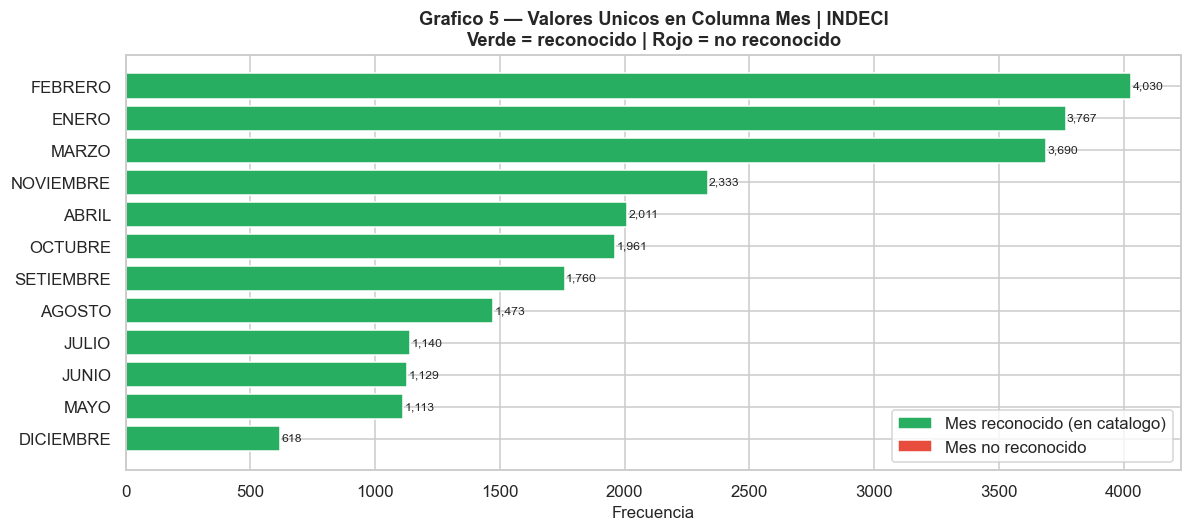

Guardado: pipeline/output/04_calidad/act04_indeci_g5_mes.png


In [10]:
print('=== AUDITORIA COLUMNA MES ===')
valores_mes = df_indeci['mes'].value_counts().sort_index()
print(f'Valores unicos en columna mes: {df_indeci["mes"].nunique()}')
print()
print('Distribucion de valores:')
print(valores_mes.to_string())
print()

# Verificar si son texto o numero
es_texto = df_indeci['mes'].apply(lambda x: isinstance(x, str) and not str(x).isdigit()).any()
print(f'Columna mes contiene texto (nombres de meses): {es_texto}')

# Grafico G5: distribucion de valores en mes
fig, ax = plt.subplots(figsize=(11, 5))
valores_mes_plot = valores_mes.sort_values(ascending=True)
colors_mes = ['#27ae60' if str(v).upper() in MESES_ES else '#e74c3c'
              for v in valores_mes_plot.index]
ax.barh(valores_mes_plot.index.astype(str), valores_mes_plot.values,
        color=colors_mes, edgecolor='white')
for i, val in enumerate(valores_mes_plot.values):
    ax.text(val+5, i, f'{int(val):,}', va='center', fontsize=8)
ax.set_xlabel('Frecuencia', fontsize=11)
ax.set_title('Grafico 5 — Valores Unicos en Columna Mes | INDECI\n'
             'Verde = reconocido | Rojo = no reconocido',
             fontsize=12, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#27ae60', label='Mes reconocido (en catalogo)'),
                   Patch(facecolor='#e74c3c', label='Mes no reconocido')])
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_indeci_g5_mes.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Columna mes en formato texto español (ENERO, FEBRERO...) en lugar de numero  
**Magnitud:** Todos los registros afectados — es el formato nativo del shapefile  
**Decision (Actividad 5):** En la Actividad 5 se aplicara un mapeo MESES_ES para convertir a numero (1-12).


## 4.3 Fenomenos Fuera del Catalogo


In [11]:
FENOMENOS_VALIDOS = [normalizar(f) for f in CONFIG['fenomenos_indeci']]
df_indeci['fenomeno_norm'] = df_indeci['fenomeno'].apply(normalizar)

en_catalogo = df_indeci['fenomeno_norm'].isin(FENOMENOS_VALIDOS)
fuera_catalogo = df_indeci[~en_catalogo]['fenomeno_norm'].value_counts()

print(f'Total registros: {len(df_indeci):,}')
print(f'En catalogo agricola: {en_catalogo.sum():,} ({en_catalogo.mean()*100:.1f}%)')
print(f'Fuera del catalogo: {(~en_catalogo).sum():,} ({(~en_catalogo).mean()*100:.1f}%)')
print()
print('Top 15 fenomenos fuera del catalogo:')
print(fuera_catalogo.head(15).to_string())
print()
print('Catalogo de fenomenos validos:')
print(FENOMENOS_VALIDOS)


Total registros: 25,025
En catalogo agricola: 13,487 (53.9%)
Fuera del catalogo: 11,538 (46.1%)

Top 15 fenomenos fuera del catalogo:
fenomeno_norm
INCENDIOS                           2368
INCENDIOS URBANOS                   2038
INCENDIOS FORESTALES                1553
GRANIZADAS                           679
PRECIPITACIONES - GRANIZO            657
TEMPORALES (VIENTOS CON LLUVIAS)     589
SISMOS                               521
HUAYCOS                              406
DEFICIT HIDRICO                      406
INUNDACION POR DESBORDE DE RIO       397
DERRUMBE CERROS                      381
DERRUMBES                            265
COLAPSO POR ANTIGUEDAD               241
PRECIPITACIONES - NEVADA             169
NEVADAS                              149

Catalogo de fenomenos validos:
['LLUVIAS INTENSAS', 'INUNDACION', 'HUAYCO', 'SEQUIA', 'HELADAS', 'FRIAJE', 'GRANIZADA', 'NEVADA', 'VIENTOS FUERTES', 'DESLIZAMIENTO', 'EROSION']


### Decision tecnica documentada

**Problema:** Registros con fenomenos no relevantes para agricultura (accidentes, incendios, etc.)  
**Magnitud:** Ver porcentaje fuera del catalogo arriba  
**Decision (Actividad 5):** En la Actividad 5 se filtrara el dataset conservando solo los fenomenos del catalogo agricola.


## 4.4 Cobertura Temporal por Año y Mes


Cobertura por año y mes:
mes_num     1     2     3     4    5    6    7    8    9     10    11   12
anho_int                                                                  
2021      1533  1407  1748  1054  608  529  560  823  890   852  1035  136
2022      1096  1485  1942   957  505  600  580  650  870  1109  1298  482
2023      1138  1138     0     0    0    0    0    0    0     0     0    0


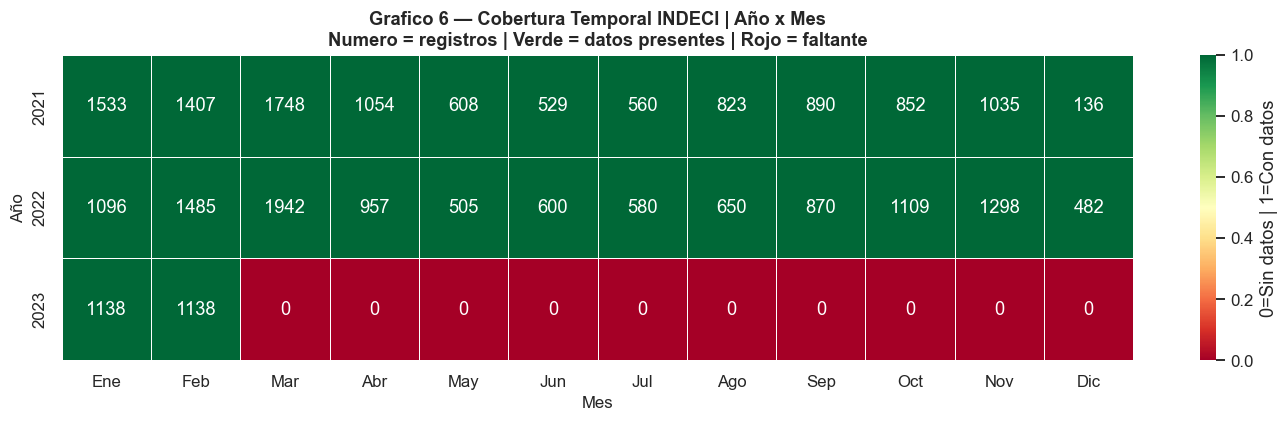

Guardado: pipeline/output/04_calidad/act04_indeci_g6_cobertura.png


In [12]:
# Mapear mes a numero
def mes_a_num(v):
    try:
        n = int(v)
        return n if 1 <= n <= 12 else None
    except (ValueError, TypeError):
        return MESES_ES.get(str(v).upper().strip(), None)

df_indeci['mes_num'] = df_indeci['mes'].apply(mes_a_num)
df_indeci['anho_int'] = pd.to_numeric(df_indeci['anho'], errors='coerce')

cobertura = df_indeci.groupby(['anho_int','mes_num']).size().unstack(fill_value=0)
cobertura_bool = (cobertura > 0).astype(int)

print('Cobertura por año y mes:')
print(cobertura.to_string())

# Grafico G6
fig, ax = plt.subplots(figsize=(13, 4))
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
cobertura_bool.columns = [meses_nombres[int(c)-1] if pd.notna(c) and 1<=int(c)<=12
                           else str(c) for c in cobertura_bool.columns]
sns.heatmap(cobertura_bool, annot=cobertura.values, fmt='d',
            cmap='RdYlGn', ax=ax, linewidths=0.5,
            cbar_kws={'label': '0=Sin datos | 1=Con datos'})
ax.set_title('Grafico 6 — Cobertura Temporal INDECI | Año x Mes\n'
             'Numero = registros | Verde = datos presentes | Rojo = faltante',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('Año', fontsize=11)
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_indeci_g6_cobertura.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Cobertura temporal incompleta en algunos meses (shapefile E_2023 es parcial)  
**Magnitud:** Ver heatmap — meses faltantes en 2023  
**Decision (Actividad 5):** En la Actividad 6 se complementara con los resumenes Excel para los meses faltantes.


## 4.5 Consistencia Shapefiles vs Resumenes Excel


In [13]:
# Cargar resumen Excel para comparar totales
xlsx_files = glob.glob(SOURCES['indeci_resumenes'] + '*.xlsx')
print(f'Archivos Excel disponibles: {len(xlsx_files)}')
for f in xlsx_files:
    df_res = pd.read_excel(f, sheet_name=0)
    print(f'  {os.path.basename(f)}: {df_res.shape}')

print()
print(f'Total registros en shapefiles: {len(df_indeci):,}')
print(f'Años cubiertos en shapefiles: {sorted(df_indeci["anho_int"].dropna().unique().astype(int).tolist())}')

# Reporte de calidad INDECI
reporte = [
    'REPORTE DE CALIDAD — INDECI SHAPEFILES',
    '=' * 60,
    f'Registros totales: {len(df_indeci):,}',
    f'En catalogo agricola: {en_catalogo.sum():,} ({en_catalogo.mean()*100:.1f}%)',
    f'Fuera del catalogo: {(~en_catalogo).sum():,} ({(~en_catalogo).mean()*100:.1f}%)',
    f'Columna mes en texto: {es_texto}',
    f'Nulos en fenomeno: {df_indeci["fenomeno"].isnull().sum()}',
    f'Nulos en departamento: {df_indeci["departamen"].isnull().sum()}',
]
reporte_txt = '\n'.join(reporte)
print()
print(reporte_txt)
with open(OUTPUT['calidad'] + 'reporte_calidad_indeci.txt', 'w', encoding='utf-8') as f:
    f.write(reporte_txt)
print()
print('[ACTIVIDAD 4 - INDECI] COMPLETADA.')


Archivos Excel disponibles: 4
  piura_emergencias.xlsx: (100, 18)
  piura_peligros.xlsx: (114, 22)
  resumen_emergencias_2003_2024.xlsx: (35, 17)
  resumen_peligros_2003_2024.xlsx: (30, 28)

Total registros en shapefiles: 25,025
Años cubiertos en shapefiles: [2021, 2022, 2023]

REPORTE DE CALIDAD — INDECI SHAPEFILES
Registros totales: 25,025
En catalogo agricola: 13,487 (53.9%)
Fuera del catalogo: 11,538 (46.1%)
Columna mes en texto: True
Nulos en fenomeno: 0
Nulos en departamento: 0

[ACTIVIDAD 4 - INDECI] COMPLETADA.


---
# 3. Calidad — NASA POWER


## Carga de datos


In [14]:
df_nasa = pd.read_csv(OUTPUT['lectura'] + 'nasa_long_raw.csv', low_memory=False)
VARS_CLIMA = [c for c in df_nasa.columns if c not in ['DEPARTAMENTO','PROVINCIA','YEAR','MES']]
RANGOS = CONFIG.get('RANGOS_VALIDOS', {
    'T2M': [-10.0, 50.0], 'T2M_MAX': [-5.0, 55.0], 'T2M_MIN': [-20.0, 40.0],
    'PRECTOTCORR': [0.0, 50.0], 'RH2M': [0.0, 100.0], 'QV2M': [0.0, 30.0],
    'ALLSKY_SFC_SW_DWN': [0.0, 35.0], 'WS2M': [0.0, 20.0]
})
print(f'Shape: {df_nasa.shape}')
print(f'Variables climaticas: {VARS_CLIMA}')


Shape: (6120, 12)
Variables climaticas: ['ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M']


## 4.1 Auditoria de Nulos por Variable


=== NULOS POR VARIABLE CLIMATICA ===
  ALLSKY_SFC_SW_DWN           102 nulos (1.67%)  [REQUIERE IMPUTACION]
  PRECTOTCORR                   0 nulos (0.00%)  [OK]
  QV2M                          0 nulos (0.00%)  [OK]
  RH2M                          0 nulos (0.00%)  [OK]
  T2M                           0 nulos (0.00%)  [OK]
  T2M_MAX                       0 nulos (0.00%)  [OK]
  T2M_MIN                       0 nulos (0.00%)  [OK]
  WS2M                          0 nulos (0.00%)  [OK]


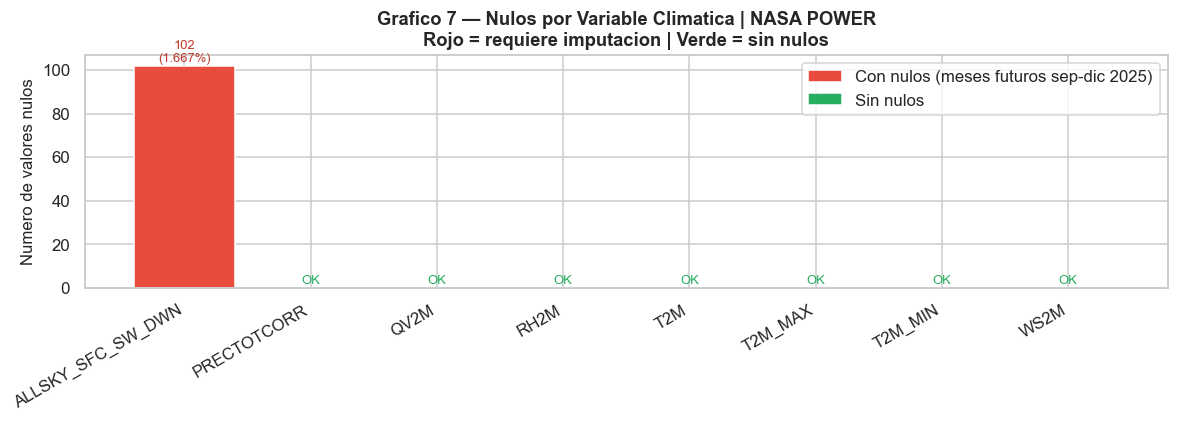

Guardado: pipeline/output/04_calidad/act04_nasa_g7_nulos.png


In [15]:
nulos_nasa = df_nasa[VARS_CLIMA].isnull().sum()
pct_nasa   = (nulos_nasa / len(df_nasa) * 100).round(3)

print('=== NULOS POR VARIABLE CLIMATICA ===')
for var, n, p in zip(nulos_nasa.index, nulos_nasa.values, pct_nasa.values):
    nivel = 'REQUIERE IMPUTACION' if n > 0 else 'OK'
    print(f'  {var:<25} {n:>5,} nulos ({p:.2f}%)  [{nivel}]')

# Grafico G7
fig, ax = plt.subplots(figsize=(11, 4))
colors_n = ['#e74c3c' if n > 0 else '#27ae60' for n in nulos_nasa.values]
bars = ax.bar(nulos_nasa.index, nulos_nasa.values, color=colors_n, edgecolor='white')
for bar, val, p in zip(bars, nulos_nasa.values, pct_nasa.values):
    label = f'{val}\n({p}%)' if val > 0 else 'OK'
    color = '#c0392b' if val > 0 else '#27ae60'
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3 if val > 0 else 0.3,
            label, ha='center', va='bottom', fontsize=8.5, color=color)
ax.set_ylabel('Numero de valores nulos', fontsize=11)
ax.set_title('Grafico 7 — Nulos por Variable Climatica | NASA POWER\n'
             'Rojo = requiere imputacion | Verde = sin nulos',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(nulos_nasa.index, rotation=30, ha='right')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c', label='Con nulos (meses futuros sep-dic 2025)'),
                   Patch(facecolor='#27ae60', label='Sin nulos')])
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_nasa_g7_nulos.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** 102 nulos en ALLSKY_SFC_SW_DWN (meses futuros sep-dic 2025 sin datos NASA)  
**Magnitud:** 102 registros (1.7% de la variable)  
**Decision (Actividad 5):** En la Actividad 5 se imputara con interpolacion lineal (<=4 meses consecutivos por provincia).


## 4.2 Verificacion de Valores Centinela -999


In [16]:
print('=== VERIFICACION DE VALORES CENTINELA -999 ===')
centinelas = {}
for var in VARS_CLIMA:
    n_centinela = (df_nasa[var] == -999.0).sum()
    centinelas[var] = n_centinela
    if n_centinela > 0:
        print(f'  ALERTA: {var} tiene {n_centinela} valores -999 sin convertir a NaN')

total_centinelas = sum(centinelas.values())
if total_centinelas == 0:
    print('  OK: No se encontraron valores centinela -999 en ninguna variable.')
    print('  Los valores -999 fueron correctamente convertidos a NaN en la Actividad 2.')
else:
    print(f'  TOTAL centinelas residuales: {total_centinelas}')


=== VERIFICACION DE VALORES CENTINELA -999 ===
  OK: No se encontraron valores centinela -999 en ninguna variable.
  Los valores -999 fueron correctamente convertidos a NaN en la Actividad 2.


### Decision tecnica documentada

**Problema:** Valores centinela -999 de NASA POWER para datos no disponibles  
**Magnitud:** Ver resultado arriba — si hay residuales, cuantificar  
**Decision (Actividad 5):** En la Actividad 5 se aplicara df.replace(-999.0, np.nan) como medida de seguridad.


## 4.3 Verificacion de Rangos Fisicos


=== VERIFICACION DE RANGOS FISICOS ===
  ALLSKY_SFC_SW_DWN         rango [0.0, 35.0]  violaciones: 0  [OK]
  PRECTOTCORR               rango [0.0, 50.0]  violaciones: 0  [OK]
  QV2M                      rango [0.0, 30.0]  violaciones: 0  [OK]
  RH2M                      rango [0.0, 100.0]  violaciones: 0  [OK]
  T2M                       rango [-10.0, 50.0]  violaciones: 0  [OK]
  T2M_MAX                   rango [-5.0, 55.0]  violaciones: 0  [OK]
  T2M_MIN                   rango [-20.0, 40.0]  violaciones: 0  [OK]
  WS2M                      rango [0.0, 20.0]  violaciones: 0  [OK]


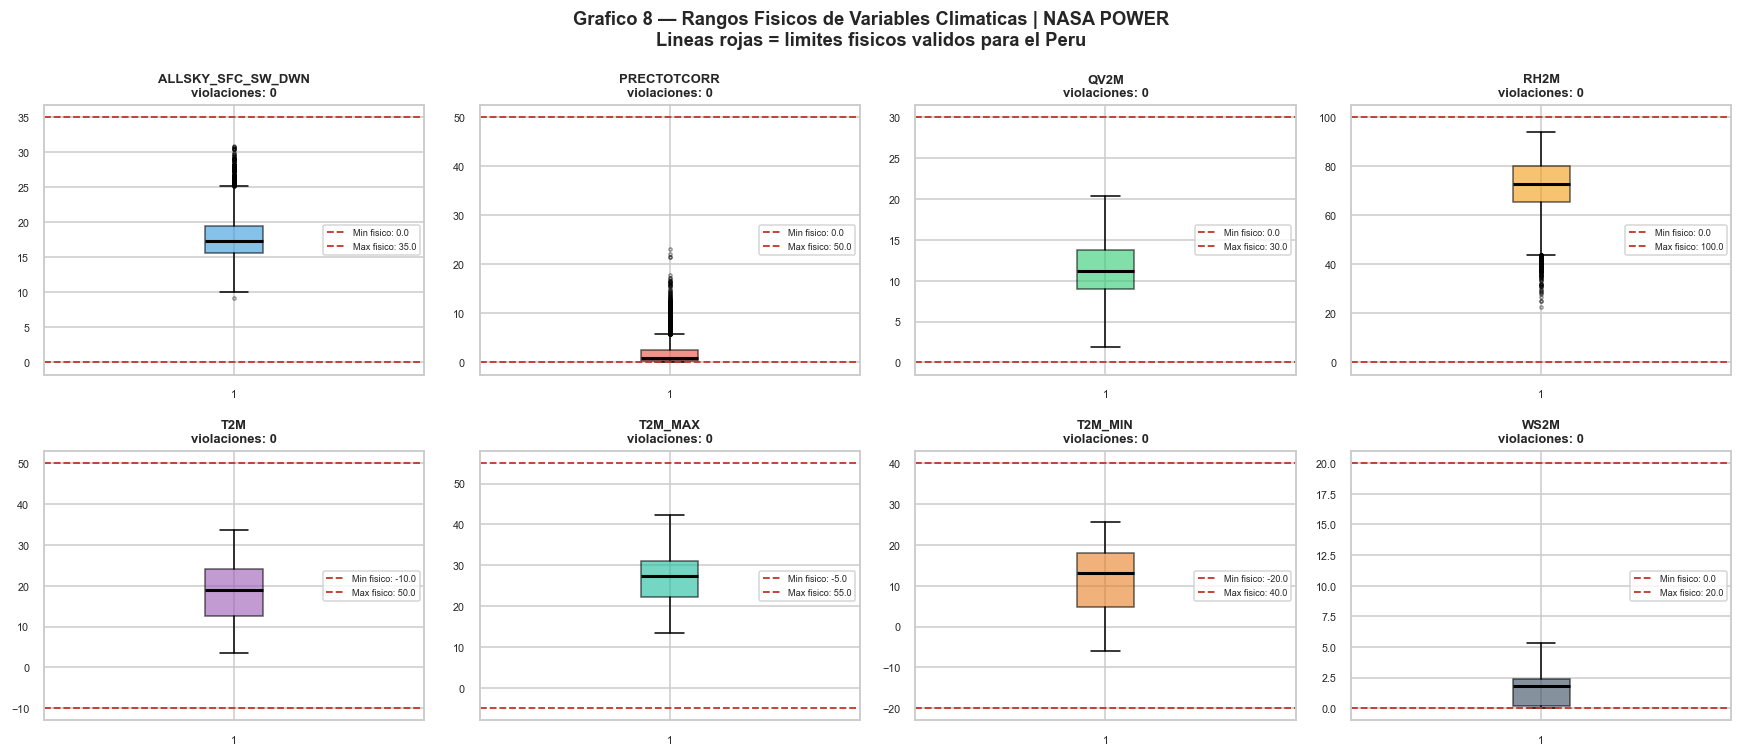

Guardado: pipeline/output/04_calidad/act04_nasa_g8_rangos.png


In [17]:
print('=== VERIFICACION DE RANGOS FISICOS ===')
violaciones = {}
for var in VARS_CLIMA:
    if var in RANGOS:
        rmin, rmax = RANGOS[var]
        data = df_nasa[var].dropna()
        fuera = ((data < rmin) | (data > rmax)).sum()
        violaciones[var] = fuera
        estado = 'ALERTA' if fuera > 0 else 'OK'
        print(f'  {var:<25} rango [{rmin}, {rmax}]  '
              f'violaciones: {fuera}  [{estado}]')

# Grafico G8: boxplots con limites fisicos
n_vars = len(VARS_CLIMA)
ncols = 4
nrows = (n_vars + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows*3.5))
axes = axes.flatten()
colores_box = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22','#34495e']

for i, (var, color) in enumerate(zip(VARS_CLIMA, colores_box)):
    data = df_nasa[var].dropna()
    bp = axes[i].boxplot(data, patch_artist=True, vert=True,
                         boxprops=dict(facecolor=color, alpha=0.6),
                         medianprops=dict(color='black', linewidth=2),
                         flierprops=dict(marker='o', color='#e74c3c',
                                         markersize=2, alpha=0.4))
    if var in RANGOS:
        rmin, rmax = RANGOS[var]
        axes[i].axhline(rmin, color='#c0392b', linestyle='--', linewidth=1.2,
                        label=f'Min fisico: {rmin}')
        axes[i].axhline(rmax, color='#c0392b', linestyle='--', linewidth=1.2,
                        label=f'Max fisico: {rmax}')
    axes[i].set_title(f'{var}\nviolaciones: {violaciones.get(var,0)}',
                      fontsize=8.5, fontweight='bold')
    axes[i].tick_params(labelsize=7)
    axes[i].legend(fontsize=6)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Grafico 8 — Rangos Fisicos de Variables Climaticas | NASA POWER\n'
             'Lineas rojas = limites fisicos validos para el Peru',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_nasa_g8_rangos.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Valores fuera de rangos fisicos posibles para el Peru  
**Magnitud:** Ver tabla de violaciones arriba  
**Decision (Actividad 5):** En la Actividad 5 se aplicara clipping a los rangos validos definidos en pipeline_config.json.


## 4.4 Saltos Temporales por Provincia


Meses esperados por provincia: 60
Provincias con serie completa: 102
Provincias con serie incompleta: 0


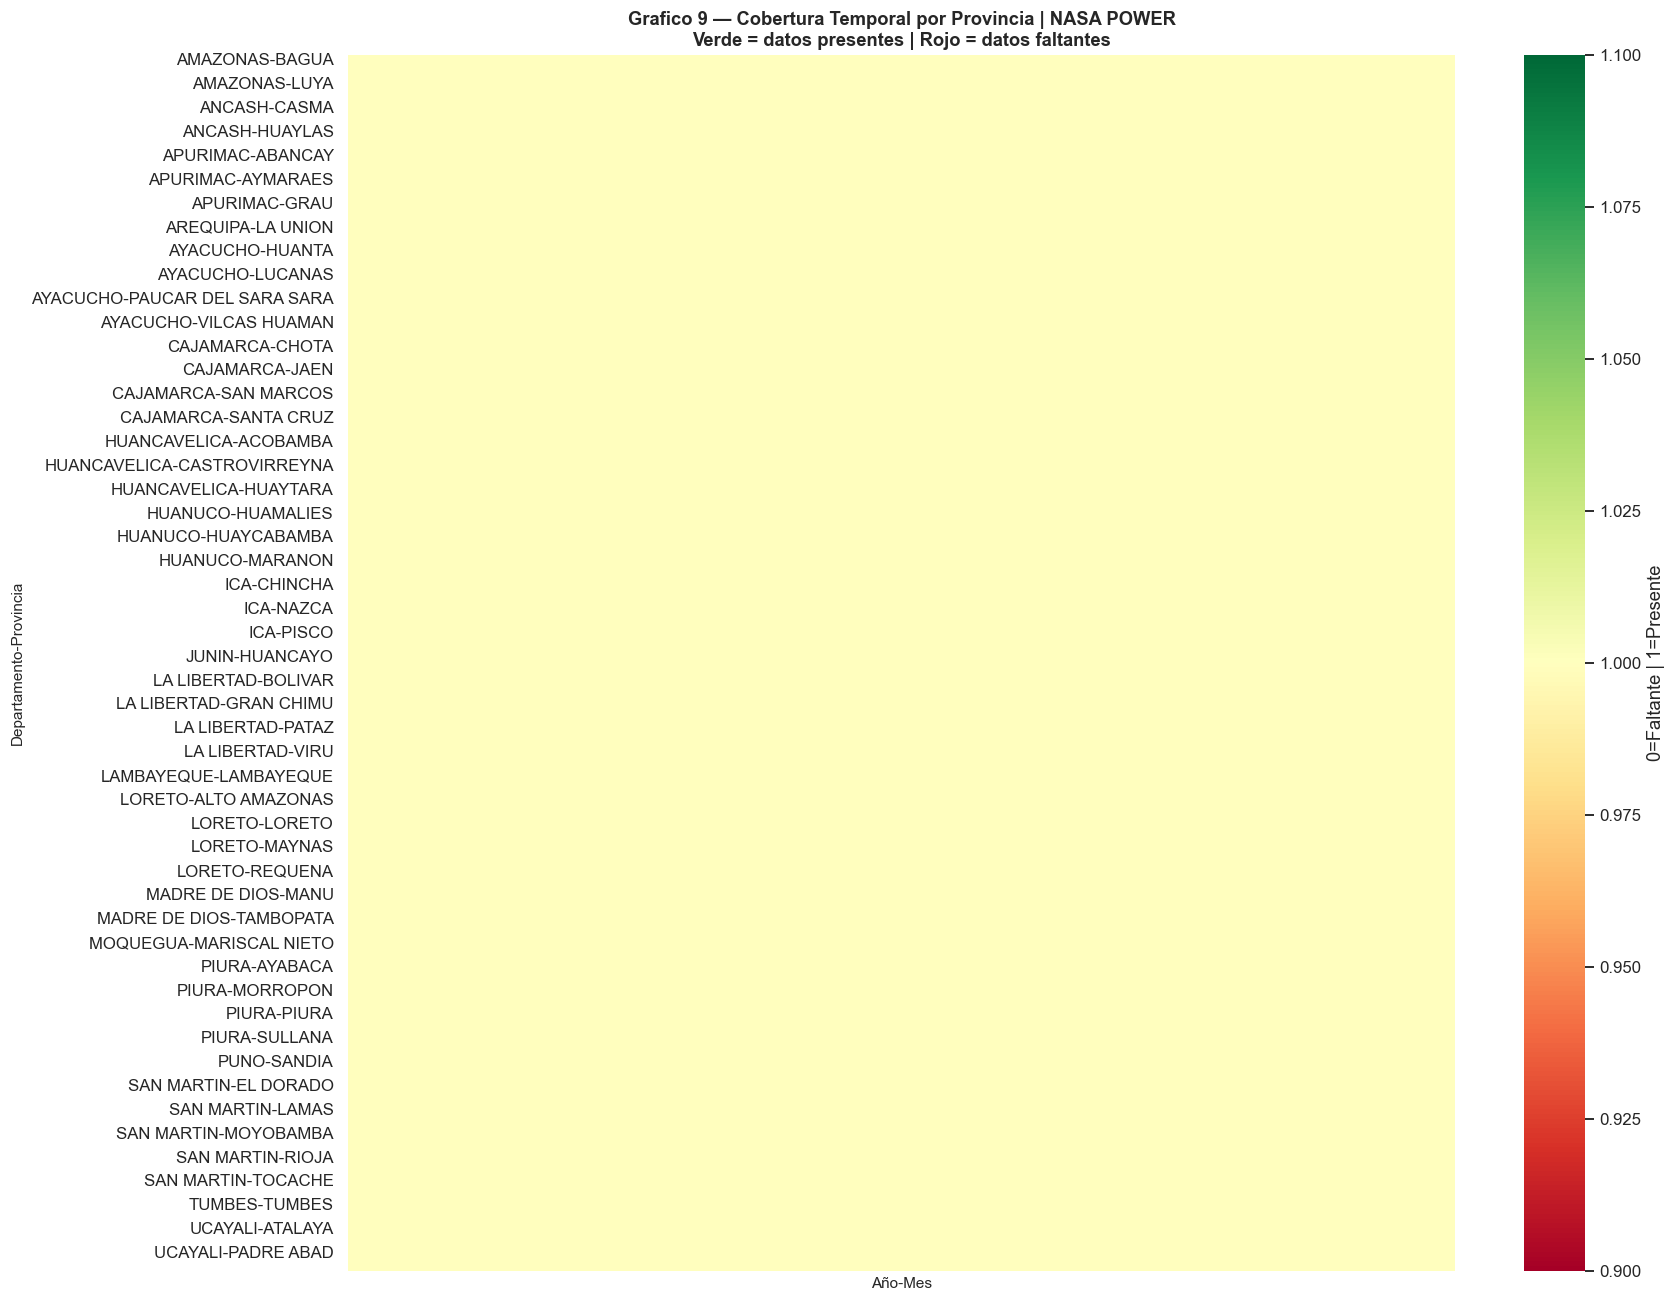

Guardado: pipeline/output/04_calidad/act04_nasa_g9_cobertura.png


In [18]:
# Verificar que cada provincia tiene los 60 meses esperados (2021-01 a 2025-12)
meses_esperados = 60  # 5 años x 12 meses
meses_por_prov = df_nasa.groupby(['DEPARTAMENTO','PROVINCIA']).size()

incompletas = meses_por_prov[meses_por_prov < meses_esperados]
completas   = meses_por_prov[meses_por_prov == meses_esperados]

print(f'Meses esperados por provincia: {meses_esperados}')
print(f'Provincias con serie completa: {len(completas)}')
print(f'Provincias con serie incompleta: {len(incompletas)}')
if len(incompletas) > 0:
    print()
    print('Provincias incompletas:')
    print(incompletas.to_string())

# Grafico G9: heatmap cobertura por provincia
cobertura_prov = df_nasa.groupby(['DEPARTAMENTO','PROVINCIA','YEAR','MES']).size().unstack(
    level=['YEAR','MES'], fill_value=0)
cobertura_bool = (cobertura_prov > 0).astype(int)

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(cobertura_bool, cmap='RdYlGn', ax=ax,
            xticklabels=False,
            cbar_kws={'label': '0=Faltante | 1=Presente'})
ax.set_title('Grafico 9 — Cobertura Temporal por Provincia | NASA POWER\n'
             'Verde = datos presentes | Rojo = datos faltantes',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Año-Mes', fontsize=10)
ax.set_ylabel('Departamento-Provincia', fontsize=10)
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_nasa_g9_cobertura.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Provincias con series temporales incompletas  
**Magnitud:** Ver tabla de provincias incompletas arriba  
**Decision (Actividad 5):** En la Actividad 5 se imputaran los meses faltantes con interpolacion lineal o media historica.


In [19]:
reporte = [
    'REPORTE DE CALIDAD — NASA POWER',
    '=' * 60,
    f'Registros totales: {len(df_nasa):,}',
    f'Variables climaticas: {len(VARS_CLIMA)}',
    f'Provincias: {df_nasa["PROVINCIA"].nunique()}',
    f'Centinelas -999 residuales: {total_centinelas}',
    f'Provincias con serie completa: {len(completas)}',
    f'Provincias con serie incompleta: {len(incompletas)}',
]
for var, n in nulos_nasa.items():
    if n > 0:
        reporte.append(f'Nulos {var}: {n} ({pct_nasa[var]:.2f}%)')
for var, n in violaciones.items():
    if n > 0:
        reporte.append(f'Violaciones rango {var}: {n}')

reporte_txt = '\n'.join(reporte)
print(reporte_txt)
with open(OUTPUT['calidad'] + 'reporte_calidad_nasa.txt', 'w', encoding='utf-8') as f:
    f.write(reporte_txt)
print()
print('[ACTIVIDAD 4 - NASA] COMPLETADA.')


REPORTE DE CALIDAD — NASA POWER
Registros totales: 6,120
Variables climaticas: 8
Provincias: 102
Centinelas -999 residuales: 0
Provincias con serie completa: 102
Provincias con serie incompleta: 0
Nulos ALLSKY_SFC_SW_DWN: 102 (1.67%)

[ACTIVIDAD 4 - NASA] COMPLETADA.


---
# 4. Calidad — Agraria.pe


## Carga de datos


In [20]:
df_agr = pd.read_csv(OUTPUT['lectura'] + 'agraria_raw.csv',
                     on_bad_lines='skip', low_memory=False)
df_agr['fecha_dt'] = pd.to_datetime(df_agr['fecha'], errors='coerce')
df_agr['anio'] = df_agr['fecha_dt'].dt.year
print(f'Shape: {df_agr.shape}')
print(f'Columnas: {df_agr.columns.tolist()}')


Shape: (528, 9)
Columnas: ['fecha', 'titular', 'cuerpo_completo', 'fuente', 'url', 'anio_archivo', 'fecha_dt', 'anio', 'mes']


## 4.1 Auditoria de Nulos


=== NULOS POR COLUMNA — AGRARIA.PE ===
  fecha                    0 nulos (0.00%)  [OK]
  titular                  0 nulos (0.00%)  [OK]
  cuerpo_completo          0 nulos (0.00%)  [OK]
  fuente                   0 nulos (0.00%)  [OK]
  url                      0 nulos (0.00%)  [OK]


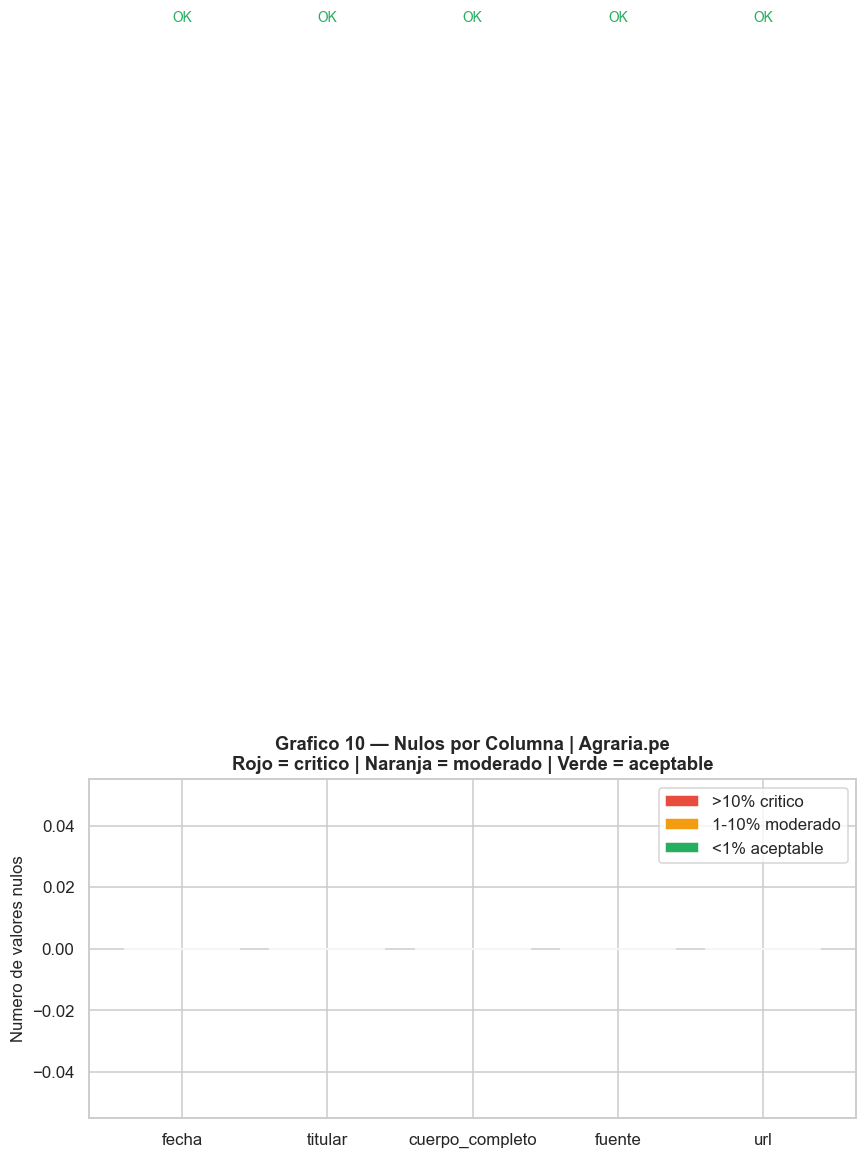

Guardado: pipeline/output/04_calidad/act04_agraria_g10_nulos.png


In [21]:
cols_check = ['fecha','titular','cuerpo_completo','fuente','url']
cols_check = [c for c in cols_check if c in df_agr.columns]
nulos_agr = df_agr[cols_check].isnull().sum()
pct_agr   = (nulos_agr / len(df_agr) * 100).round(2)

print('=== NULOS POR COLUMNA — AGRARIA.PE ===')
for col, n, p in zip(nulos_agr.index, nulos_agr.values, pct_agr.values):
    nivel = 'CRITICO' if p > 10 else 'MODERADO' if p > 1 else 'OK'
    print(f'  {col:<20} {n:>5,} nulos ({p:.2f}%)  [{nivel}]')

# Grafico G10
fig, ax = plt.subplots(figsize=(9, 4))
colors_n = ['#e74c3c' if p > 10 else '#f39c12' if p > 1 else '#27ae60'
            for p in pct_agr.values]
bars = ax.bar(nulos_agr.index, nulos_agr.values, color=colors_n, edgecolor='white')
for bar, val, p in zip(bars, nulos_agr.values, pct_agr.values):
    label = f'{val}\n({p}%)' if val > 0 else 'OK'
    color = '#c0392b' if val > 0 else '#27ae60'
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3 if val > 0 else 0.3,
            label, ha='center', va='bottom', fontsize=9, color=color)
ax.set_ylabel('Numero de valores nulos', fontsize=11)
ax.set_title('Grafico 10 — Nulos por Columna | Agraria.pe\n'
             'Rojo = critico | Naranja = moderado | Verde = aceptable',
             fontsize=12, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c', label='>10% critico'),
                   Patch(facecolor='#f39c12', label='1-10% moderado'),
                   Patch(facecolor='#27ae60', label='<1% aceptable')])
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_agraria_g10_nulos.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Decision tecnica documentada

**Problema:** Nulos en cuerpo_completo y otras columnas de texto  
**Magnitud:** Ver tabla de nulos arriba  
**Decision (Actividad 5):** En la Actividad 5 se eliminaran noticias sin titular. Las sin cuerpo se conservan para el conteo mensual.


## 4.2 Fechas Invalidas o Fuera de Rango


In [22]:
fechas_nulas = df_agr['fecha_dt'].isnull().sum()
fechas_fuera = ((df_agr['anio'] < 2021) | (df_agr['anio'] > 2025)).sum()

print(f'Fechas no parseables: {fechas_nulas} ({fechas_nulas/len(df_agr)*100:.2f}%)')
print(f'Fechas fuera del rango 2021-2025: {fechas_fuera} ({fechas_fuera/len(df_agr)*100:.2f}%)')
print()
print('Distribucion por año:')
print(df_agr['anio'].value_counts().sort_index().to_string())
print()
if fechas_nulas > 0:
    print('Muestra de fechas no parseables:')
    print(df_agr[df_agr['fecha_dt'].isnull()]['fecha'].head(5).tolist())


Fechas no parseables: 0 (0.00%)
Fechas fuera del rango 2021-2025: 0 (0.00%)

Distribucion por año:
anio
2021     44
2022    133
2023    118
2024    108
2025    125



### Decision tecnica documentada

**Problema:** Fechas no parseables o fuera del rango 2021-2025  
**Magnitud:** Ver conteo arriba  
**Decision (Actividad 5):** En la Actividad 5 se eliminaran las noticias con fecha invalida o fuera del rango del pipeline.


## 4.3 Auditoria de Duplicados


Duplicados por URL: 0 (0.00%)
Duplicados por titular+fecha: 0 (0.00%)



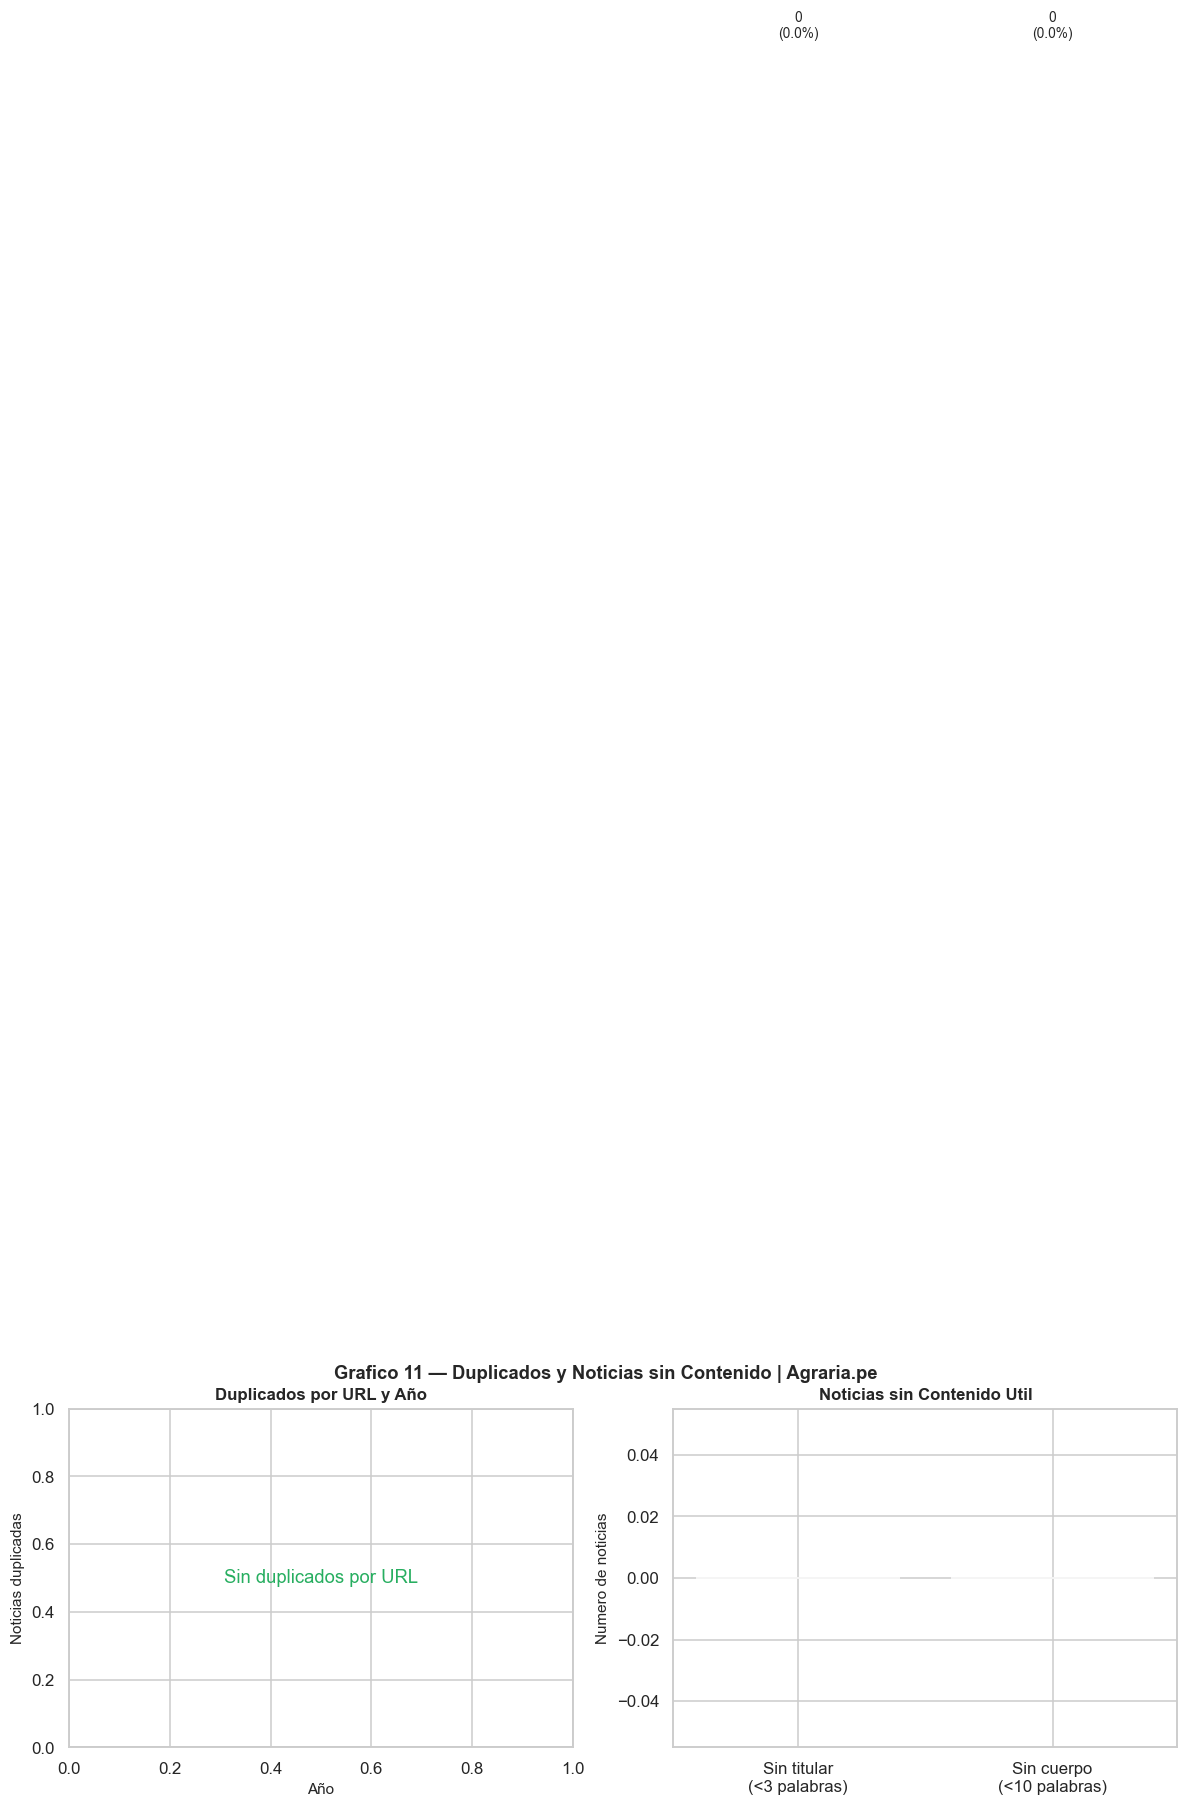

Guardado: pipeline/output/04_calidad/act04_agraria_g11_duplicados.png
Noticias sin titular util (<3 palabras): 0
Noticias sin cuerpo util (<10 palabras): 0


In [23]:
# Duplicados por URL
dup_url = df_agr['url'].duplicated().sum() if 'url' in df_agr.columns else 0
# Duplicados por titular + fecha
dup_tit = df_agr.duplicated(subset=['titular','fecha'], keep=False).sum()

print(f'Duplicados por URL: {dup_url} ({dup_url/len(df_agr)*100:.2f}%)')
print(f'Duplicados por titular+fecha: {dup_tit} ({dup_tit/len(df_agr)*100:.2f}%)')
print()

# Duplicados por año
dup_por_anio = df_agr[df_agr.duplicated(subset=['url'], keep=False)].groupby('anio').size()

# Grafico G11
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: duplicados por año
if len(dup_por_anio) > 0:
    axes[0].bar(dup_por_anio.index.astype(str), dup_por_anio.values,
                color='#e74c3c', edgecolor='white')
    for i, val in enumerate(dup_por_anio.values):
        axes[0].text(i, val+0.5, str(val), ha='center', fontsize=9)
else:
    axes[0].text(0.5, 0.5, 'Sin duplicados por URL', ha='center', va='center',
                 transform=axes[0].transAxes, fontsize=12, color='#27ae60')
axes[0].set_xlabel('Año', fontsize=10)
axes[0].set_ylabel('Noticias duplicadas', fontsize=10)
axes[0].set_title('Duplicados por URL y Año', fontsize=11, fontweight='bold')

# Panel 2: noticias sin contenido util
df_agr['len_titular'] = df_agr['titular'].fillna('').apply(lambda x: len(str(x).split()))
df_agr['len_cuerpo']  = df_agr['cuerpo_completo'].fillna('').apply(lambda x: len(str(x).split()))
sin_titular = (df_agr['len_titular'] < 3).sum()
sin_cuerpo  = (df_agr['len_cuerpo'] < 10).sum()
categorias = ['Sin titular\n(<3 palabras)', 'Sin cuerpo\n(<10 palabras)']
valores = [sin_titular, sin_cuerpo]
colors_util = ['#e74c3c' if v > 0 else '#27ae60' for v in valores]
axes[1].bar(categorias, valores, color=colors_util, edgecolor='white')
for i, val in enumerate(valores):
    axes[1].text(i, val+0.5, f'{val}\n({val/len(df_agr)*100:.1f}%)',
                 ha='center', fontsize=9)
axes[1].set_ylabel('Numero de noticias', fontsize=10)
axes[1].set_title('Noticias sin Contenido Util', fontsize=11, fontweight='bold')

plt.suptitle('Grafico 11 — Duplicados y Noticias sin Contenido | Agraria.pe',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_agraria_g11_duplicados.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print(f'Noticias sin titular util (<3 palabras): {sin_titular}')
print(f'Noticias sin cuerpo util (<10 palabras): {sin_cuerpo}')


### Decision tecnica documentada

**Problema:** Noticias duplicadas (misma URL) y noticias sin contenido util  
**Magnitud:** Ver conteo de duplicados y noticias sin contenido arriba  
**Decision (Actividad 5):** En la Actividad 5 se deduplicara por URL y se eliminaran noticias sin titular util.


In [24]:
reporte = [
    'REPORTE DE CALIDAD — AGRARIA.PE',
    '=' * 60,
    f'Noticias totales: {len(df_agr):,}',
    f'Fechas no parseables: {fechas_nulas}',
    f'Fechas fuera de rango 2021-2025: {fechas_fuera}',
    f'Duplicados por URL: {dup_url}',
    f'Duplicados por titular+fecha: {dup_tit}',
    f'Sin titular util (<3 palabras): {sin_titular}',
    f'Sin cuerpo util (<10 palabras): {sin_cuerpo}',
]
for col, n, p in zip(nulos_agr.index, nulos_agr.values, pct_agr.values):
    if n > 0:
        reporte.append(f'Nulos {col}: {n} ({p}%)')

reporte_txt = '\n'.join(reporte)
print(reporte_txt)
with open(OUTPUT['calidad'] + 'reporte_calidad_agraria.txt', 'w', encoding='utf-8') as f:
    f.write(reporte_txt)
print()
print('[ACTIVIDAD 4 - AGRARIA.PE] COMPLETADA.')


REPORTE DE CALIDAD — AGRARIA.PE
Noticias totales: 528
Fechas no parseables: 0
Fechas fuera de rango 2021-2025: 0
Duplicados por URL: 0
Duplicados por titular+fecha: 0
Sin titular util (<3 palabras): 0
Sin cuerpo util (<10 palabras): 0

[ACTIVIDAD 4 - AGRARIA.PE] COMPLETADA.


---
# 5. Resumen Consolidado de Calidad


  ACTIVIDAD 4 COMPLETADA — RESUMEN CONSOLIDADO DE CALIDAD

REPORTE DE CALIDAD — MIDAGRI SISAGRI
Registros totales: 1,596,748
Registros LIMON: 40,284
Departamentos unicos: 25
Variantes de nombre en dptos: 0
Variantes de nombre en provs: 0
Outliers PRODUCCION(t): 5,924 (14.7%)
Outliers MTO_PRECCHAC (S/ x kg): 2,838 (7.0%)
Outliers COSECHA (ha): 387 (15.3%)

REPORTE DE CALIDAD — INDECI SHAPEFILES
Registros totales: 25,025
En catalogo agricola: 13,487 (53.9%)
Fuera del catalogo: 11,538 (46.1%)
Columna mes en texto: True
Nulos en fenomeno: 0
Nulos en departamento: 0

REPORTE DE CALIDAD — NASA POWER
Registros totales: 6,120
Variables climaticas: 8
Provincias: 102
Centinelas -999 residuales: 0
Provincias con serie completa: 102
Provincias con serie incompleta: 0
Nulos ALLSKY_SFC_SW_DWN: 102 (1.67%)

REPORTE DE CALIDAD — AGRARIA.PE
Noticias totales: 528
Fechas no parseables: 0
Fechas fuera de rango 2021-2025: 0
Duplicados por URL: 0
Duplicados por titular+fecha: 0
Sin titular util (<3 palabras

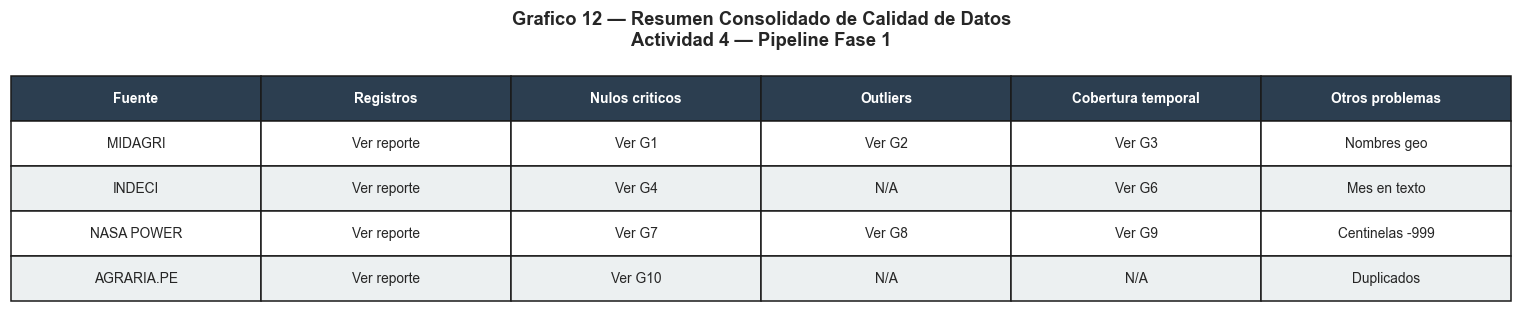

Guardado: pipeline/output/04_calidad/act04_resumen_consolidado.png

Proximos pasos:
  Actividad 5 -> Limpieza y estandarizacion (pipeline/actividad_05_limpieza.ipynb)


In [25]:
# Leer todos los reportes de calidad generados
reportes = [
    ('MIDAGRI',   OUTPUT['calidad'] + 'reporte_calidad_midagri.txt'),
    ('INDECI',    OUTPUT['calidad'] + 'reporte_calidad_indeci.txt'),
    ('NASA',      OUTPUT['calidad'] + 'reporte_calidad_nasa.txt'),
    ('AGRARIA',   OUTPUT['calidad'] + 'reporte_calidad_agraria.txt'),
]

print('=' * 70)
print('  ACTIVIDAD 4 COMPLETADA — RESUMEN CONSOLIDADO DE CALIDAD')
print('=' * 70)
print()

for nombre, path in reportes:
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            contenido = f.read()
        print(contenido)
        print()
    else:
        print(f'  {nombre}: reporte no encontrado en {path}')
        print(f'  Ejecutar primero el notebook de fuentes correspondiente.')
        print()

# Grafico G12: tabla resumen visual
resumen_data = {
    'Fuente': ['MIDAGRI', 'INDECI', 'NASA POWER', 'AGRARIA.PE'],
    'Registros': ['Ver reporte', 'Ver reporte', 'Ver reporte', 'Ver reporte'],
    'Nulos criticos': ['Ver G1', 'Ver G4', 'Ver G7', 'Ver G10'],
    'Outliers': ['Ver G2', 'N/A', 'Ver G8', 'N/A'],
    'Cobertura temporal': ['Ver G3', 'Ver G6', 'Ver G9', 'N/A'],
    'Otros problemas': ['Nombres geo', 'Mes en texto', 'Centinelas -999', 'Duplicados'],
}
df_resumen = pd.DataFrame(resumen_data)

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')
tabla = ax.table(
    cellText=df_resumen.values,
    colLabels=df_resumen.columns,
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ecf0f1')
    else:
        cell.set_facecolor('white')
ax.set_title('Grafico 12 — Resumen Consolidado de Calidad de Datos\n'
             'Actividad 4 — Pipeline Fase 1',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
g = OUTPUT['calidad'] + 'act04_resumen_consolidado.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print()
print('Proximos pasos:')
print('  Actividad 5 -> Limpieza y estandarizacion (pipeline/actividad_05_limpieza.ipynb)')
